In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from scipy.signal import butter, filtfilt


In [ ]:
data = pd.read_csv("/content/eda_dataset.csv")


In [ ]:
# ---------- Step 1: Simulate an EDA-like signal ----------
np.random.seed(42)
time = np.linspace(0, 300, 3000)  # 300 seconds @10Hz
eda_clean = 0.2 * np.sin(0.05 * time) + 0.05 * np.random.randn(len(time))  # smooth physiological pattern

In [ ]:
# add fake motion artifacts (spikes)
eda_noisy = eda_clean.copy()
for _ in range(20):
    i = np.random.randint(0, len(time))
    eda_noisy[i:i+10] += np.random.uniform(0.5, 1.5)


In [ ]:
# ---------- Step 2: Low-pass filter ----------
def lowpass_filter(signal, fs=10, cutoff=2.0):
    b, a = butter(3, cutoff/(fs/2), btype='low')
    return filtfilt(b, a, signal)

eda_filtered = lowpass_filter(eda_noisy)

In [ ]:
# ---------- Step 3: Create sliding window features ----------
win = 50  # window size
features = []
for i in range(0, len(eda_filtered) - win, win):
    segment = eda_filtered[i:i+win]
    feats = [np.mean(segment), np.std(segment), np.max(segment) - np.min(segment)]
    features.append(feats)
features = np.array(features)


In [ ]:
# ---------- Step 4: Apply Isolation Forest ----------
clf = IsolationForest(contamination=0.05, random_state=42)
labels = clf.fit_predict(features)  # -1 = anomaly, 1 = normal

In [ ]:
# ---------- Step 5: Mark artifact regions ----------
artifact_idx = np.where(labels == -1)[0]
artifact_mask = np.zeros(len(eda_filtered))
for idx in artifact_idx:
    artifact_mask[idx*win:(idx+1)*win] = 1

eda_cleaned = eda_filtered.copy()
eda_cleaned[artifact_mask == 1] = np.median(eda_filtered)  # replace artifact windows with median

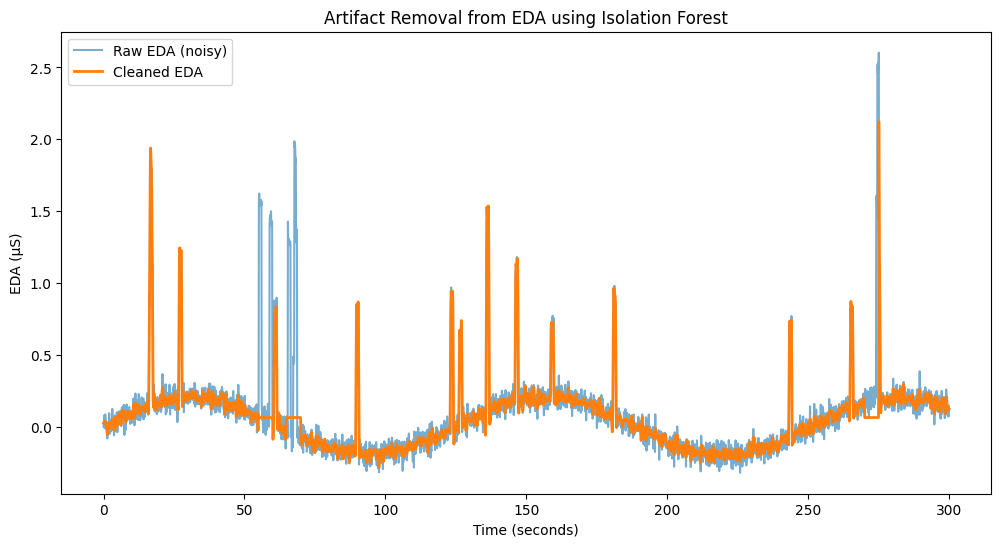

In [ ]:
# ---------- Step 6: Plot Results ----------
plt.figure(figsize=(12,6))
plt.plot(time, eda_noisy, label='Raw EDA (noisy)', alpha=0.6)
plt.plot(time, eda_cleaned, label='Cleaned EDA', linewidth=2)
plt.xlabel("Time (seconds)")
plt.ylabel("EDA (µS)")
plt.title("Artifact Removal from EDA using Isolation Forest")
plt.legend()
plt.show()